In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make plots look nicer
sns.set(style="whitegrid")

In [40]:
df = pd.read_csv("../data/raw_data.csv")

df.head()

,Dp_tp [kPa],p_avg_rel [kPa],p_avg_abs [Pa],Q_l [nl/h],Q_g [nl/h],T_l [K],T_g [K],p_eff_g [Pa]
0,0.740692,5.772259,107097.2586,10,500,300.65,295.15,400000
1,0.908420,6.257012,107582.0118,10,1000,300.65,295.15,400000
2,1.710984,7.235408,108560.4083,10,1500,300.65,295.15,400000
3,2.426009,8.513364,109838.3639,10,2000,300.65,295.15,400000
4,3.097317,10.138551,111463.5511,10,2500,300.65,295.15,400000


In [41]:
df.info()
df.describe()
df = df.drop(["p_avg_abs [Pa]", "p_avg_rel [kPa]"], axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Dp_tp [kPa]      119 non-null    float64
 1   p_avg_rel [kPa]  119 non-null    float64
 2   p_avg_abs [Pa]   119 non-null    float64
 3   Q_l [nl/h]       119 non-null    int64  
 4   Q_g [nl/h]       119 non-null    int64  
 5   T_l [K]          119 non-null    float64
 6   T_g [K]          119 non-null    float64
 7   p_eff_g [Pa]     119 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 7.6 KB


In [10]:
# Convert pressure drop from kPa → Pa
df["Dp_tp [kPa]"] = df["Dp_tp [kPa]"] * 1000

# Convert flow rates from nl/h → m^3/s
df["Q_l [nl/h]"] = df["Q_l [nl/h]"] * 1e-9 / 3600
df["Q_g [nl/h]"] = df["Q_g [nl/h]"] * 1e-9 / 3600

In [11]:
df.isnull().sum()

Dp_tp [kPa]        0
p_avg_rel [kPa]    0
p_avg_abs [Pa]     0
Q_l [nl/h]         0
Q_g [nl/h]         0
T_l [K]            0
T_g [K]            0
p_eff_g [Pa]       0
dtype: int64

In [27]:
# total flow
df["Q_total"] = df["Q_l [nl/h]"] + df["Q_g [nl/h]"]

# gas fraction
df["gas_fraction"] = df["Q_g [nl/h]"] / (df["Q_total"] + 1e-8)

# flow ratio
df["flow_ratio"] = df["Q_g [nl/h]"] / (df["Q_l [nl/h]"] + 1e-8)

# temperature difference
df["delta_T"] = df["T_l [K]"] - df["T_g [K]"]

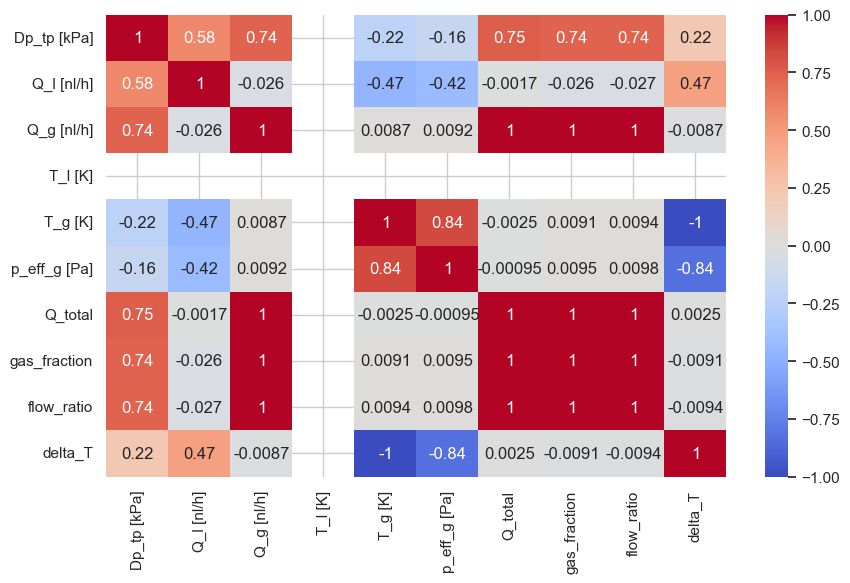

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

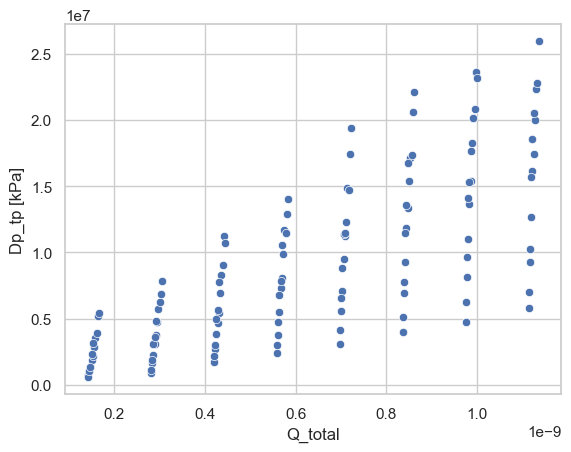

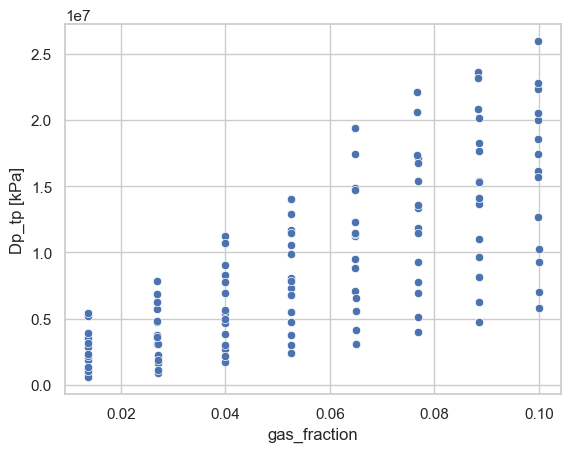

In [29]:
sns.scatterplot(x="Q_total", y="Dp_tp [kPa]", data=df)
plt.show()

sns.scatterplot(x="gas_fraction", y="Dp_tp [kPa]", data=df)
plt.show()

In [30]:
X = df.drop("Dp_tp [kPa]", axis=1)
y = df["Dp_tp [kPa]"]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [34]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} RMSE:", rmse)
    print(f"{name} R2:", r2)
    print("-----")

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")

Linear Regression RMSE: 3438044.771720786
Linear Regression R2: 0.6919608462727274
-----
Random Forest RMSE: 1531902.0419339018
Random Forest R2: 0.9388431855386747
-----


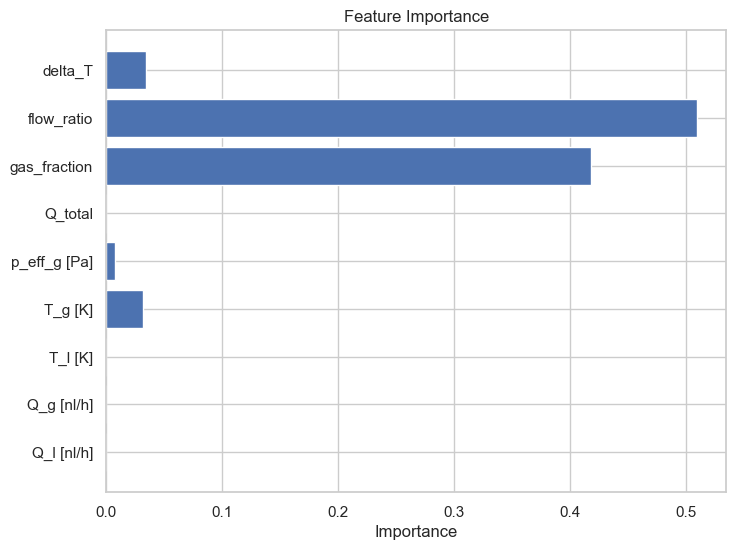

In [35]:
importances = rf.feature_importances_

plt.figure(figsize=(8,6))
plt.barh(X.columns, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()